2026-01-16 10-10-51
Outputs will be written to: results/run_2026-01-16 10-10-51
Saved a copy of the config : results/run_2026-01-16 10-10-51/config_copy.yaml
Inputs shape: (41, 6)
Outputs shape: (41,)
First 20 rows of raw data:
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score   source
32     0.038479     0.518839     0.311248     0.237261     0.417124     0.684376  1.415182   week-3
6      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968     file
30     0.000000     0.500000     0.214286     0.214286     0.428572     0.714286  1.181423   week-1
37     0.067812     0.504863     0.287394     0.230127     0.473182     0.728104  1.124186   week-8
31     0.060606     0.484848     0.242424     0.181818     0.484848     0.727273  0.976917   week-2
36     0.056006     0.252690     0.914472     0.121294     0.362425     1.007224  0.916195   week-7
38     0.049863     0.526174     0.301564     0.217309     0.491237     

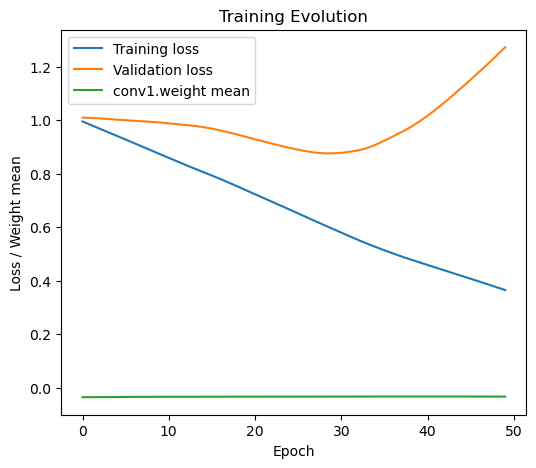

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
sample_strategy=sobol, Final sample shape: (1000000, 6)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 5
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.98519104, 1.08913341, 1.13131456, 0.34678632, 0.45721717,
       1.19663689]), 'score': 0.005329543813216472, 'dim': 6, 'predicted_y': 0.40094557, 'improvement_over_input_model': -0.12406799, 'distance_to_best_input': 1.1667776031387338}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([0.98519104, 1.08913341, 1.13131456, 0.34678632, 0.45721717,
       1.19663689]), 'score': 0.0041215463298091, 'dim': 6, 'predicted_y': 0.40094557, 'improvement_over_input_model': -0.12406799, 'distance_to_best_input': 1.1667776031387338}
{'method': 'EI', 'xi': 0.2, 'kappa': None, 'x': array([0.98519104,

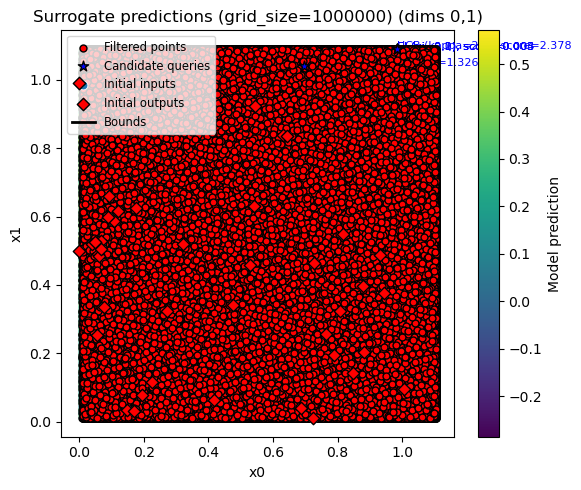

Saved dataframe to: results/run_2026-01-16 10-10-51/df_grid_1000000_stride6_None_max_raw_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 2.0, 'x': array([0.98519104, 1.08913341, 1.13131456, 0.34678632, 0.45721717,
       1.19663689]), 'score': 2.3780614870377565, 'dim': 6, 'predicted_y': 0.40094557, 'improvement_over_input_model': -0.12406799, 'distance_to_best_input': 1.1667776031387338, 'best_input_x': array([0.      , 0.99097 , 0.990603, 0.      , 0.      , 1.017683]), 'best_input_pred': 0.52501357}
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score   source  score-scaled
0      0.985191     1.089133     1.131315     0.346786     0.457217     1.196637  2.378061   week-x     10.000000
1      0.038479     0.518839     0.311248     0.237261     0.417124     0.684376  1.415182   week-3      5.950991
2      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968     file      5.739836
3      0.69

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))